# EEG Emotion Recognition Project

This notebook implements the first part of the project pipeline:

1. Load SEED-V metadata.
2. Inspect emotion labels and trial timestamps.
3. Estimate the number of EEG segments per class.
4. Load `.cnt` EEG recordings with MNE.
5. Apply basic preprocessing.
6. Segment trials into fixed-length windows.
7. Prepare train/validation/test splits.

The CNN models will be added after the dataset-building pipeline is verified.

## 0. Installation notes

Run the following cell only if the required packages are missing in the current environment.

In Google Colab, `mne` is usually not installed by default.

In [5]:
# Uncomment if needed
# !pip install mne openpyxl scikit-learn tensorflow
# from google.colab import drive
# drive.mount('/content/drive')

## 1. Imports, global configuration and experiment flags

This section defines paths, preprocessing parameters and execution flags.

Expensive steps are cached:

- raw `.cnt` preprocessing + segmentation is saved under `outputs/datasets/...`;
- trained Keras models are saved under `outputs/models/...`;
- result tables are saved under `outputs/results/...`.

Changing `window_seconds`, `RESAMPLE_FREQ`, filter bounds or model type creates separate folders, so experiments do not overwrite each other.

In [6]:
from pathlib import Path
import re
import json
import time
import warnings
from contextlib import contextmanager

# Suppress MNE-Python warning about missing measurement date in .cnt file
warnings.filterwarnings(
    "ignore", category=RuntimeWarning, message=".*Could not parse meas date.*"
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

try:
    import mne
except ImportError:
    mne = None
    warnings.warn("MNE is not installed. Install it with: pip install mne")

RANDOM_STATE = 0

# Change this path in Colab/local environment
PROJECT_ROOT = Path(".")
DATASET_DIR = PROJECT_ROOT / "dataset_instructions"
EEG_RAW_DIR = PROJECT_ROOT / "EEG_raw"

TIMESTAMP_FILE = DATASET_DIR / "trial_start_end_timestamp.txt"
EMOTION_ORDER_FILE = DATASET_DIR / "emotion_label_and_stimuli_order.xlsx"

# Baseline requested by the project
DEFAULT_WINDOW_SECONDS = 1.5

# Preprocessing parameters
DROP_CHANNELS = ["M1", "M2", "VEO", "HEO"]
LOW_FREQ = 1.0
HIGH_FREQ = 50.0
RESAMPLE_FREQ = 250.0  # Example: 250.0, 128.0, or None to keep original sampling frequency

# ------------------------------------------------------------
# Execution flags
# ------------------------------------------------------------
# Dataset cache
USE_DATASET_CACHE = True          # Load cached segmented files when available
FORCE_REBUILD_DATASET = False     # Recompute segments even if cache exists
SAVE_DATASET_CACHE = True         # Save segmented data to disk

# Baseline models at DEFAULT_WINDOW_SECONDS / RESAMPLE_FREQ
RUN_BASELINE_1D = False
RUN_BASELINE_2D = False
TRAIN_BASELINE_1D = False         # If False, load model if it exists; train only if missing
TRAIN_BASELINE_2D = False
FORCE_RETRAIN_BASELINE_1D = False
FORCE_RETRAIN_BASELINE_2D = False

# Open-problem window experiments
RUN_WINDOW_EXPERIMENTS = True
WINDOW_SECONDS_LIST = [1.0, 1.5, 2.0]
TRAIN_WINDOW_1D = True
TRAIN_WINDOW_2D = True
FORCE_RETRAIN_WINDOW_MODELS = False

# Optional resampling-frequency experiments
RUN_RESAMPLE_EXPERIMENTS = False
RESAMPLE_FREQ_LIST = [128.0, 250.0]  # Add None to test original sampling rate
TRAIN_RESAMPLE_1D = True
TRAIN_RESAMPLE_2D = False            # 2D is much slower; enable only if needed
FORCE_RETRAIN_RESAMPLE_MODELS = False

# Training hyperparameters
EPOCHS = 30
BATCH_SIZE = 64
PATIENCE = 8
EXPERIMENT_EPOCHS = 20
EXPERIMENT_PATIENCE = 6
USE_CLASS_WEIGHTS = True

# Output folders
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATASET_CACHE_ROOT = OUTPUT_DIR / "datasets"
MODEL_CACHE_ROOT = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"
PLOTS_DIR = OUTPUT_DIR / "plots"
CONFUSION_MATRICES_DIR = OUTPUT_DIR / "confusion_matrices"
SCORES_DIR = OUTPUT_DIR / "scores"

# Every stochastic run is stored under a seed-specific namespace.
# This prevents runs with the same preprocessing/training variables but
# different RANDOM_STATE values from overwriting each other.
SEED_TAG = f"seed_{RANDOM_STATE}"
RESULTS_SEED_DIR = RESULTS_DIR / SEED_TAG
PLOTS_SEED_DIR = PLOTS_DIR / SEED_TAG
CONFUSION_MATRICES_SEED_DIR = CONFUSION_MATRICES_DIR / SEED_TAG
SCORES_SEED_DIR = SCORES_DIR / SEED_TAG

for folder in [
    OUTPUT_DIR,
    DATASET_CACHE_ROOT,
    MODEL_CACHE_ROOT,
    RESULTS_DIR,
    PLOTS_DIR,
    CONFUSION_MATRICES_DIR,
    SCORES_DIR,
    RESULTS_SEED_DIR,
    PLOTS_SEED_DIR,
    CONFUSION_MATRICES_SEED_DIR,
    SCORES_SEED_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

LABEL_TO_ID = {
    "Disgust": 0,
    "Fear": 1,
    "Sad": 2,
    "Neutral": 3,
    "Happy": 4,
}

ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
CLASS_NAMES = [ID_TO_LABEL[i] for i in range(len(ID_TO_LABEL))]
N_CLASSES = len(CLASS_NAMES)


def _safe_float_token(value, suffix=""):
    """Convert a number to a filesystem-friendly token."""
    if value is None:
        return f"orig{suffix}"
    token = str(float(value)).replace(".", "p")
    return f"{token}{suffix}"


def _safe_name_token(value) -> str:
    """Convert free text to a filesystem-friendly token."""
    token = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")
    return token.lower() or "run"


def seed_tag(random_state: int = RANDOM_STATE) -> str:
    """Create the seed token used in output paths."""
    return f"seed_{int(random_state)}"


def experiment_tag(
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
) -> str:
    """Create a stable tag for cache/model folders."""
    return "_".join([
        f"win_{_safe_float_token(window_seconds, 's')}",
        f"rs_{_safe_float_token(resample_freq, 'Hz')}",
        f"lf_{_safe_float_token(low_freq, 'Hz')}",
        f"hf_{_safe_float_token(high_freq, 'Hz')}",
    ])


def dataset_cache_dir(
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
) -> Path:
    """Folder where segmented EEG data for a specific configuration is cached."""
    return DATASET_CACHE_ROOT / experiment_tag(window_seconds, resample_freq, low_freq, high_freq)


def model_cache_dir(
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    random_state: int = RANDOM_STATE,
) -> Path:
    """Folder where trained models for a specific configuration and seed are cached."""
    return MODEL_CACHE_ROOT / seed_tag(random_state) / experiment_tag(window_seconds, resample_freq, low_freq, high_freq)


def run_output_tag(
    model_kind: str,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    random_state: int = RANDOM_STATE,
) -> str:
    """Create a unique tag for plots, scores, reports and confusion matrices."""
    return "_".join([
        experiment_tag(window_seconds, resample_freq, low_freq, high_freq),
        seed_tag(random_state),
        _safe_name_token(model_kind),
    ])


@contextmanager
def timed(label: str):
    """Print elapsed time for expensive notebook steps."""
    start = time.perf_counter()
    print(f"[START] {label}")
    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        print(f"[END] {label} - elapsed: {elapsed:.2f}s ({elapsed/60:.2f} min)")


print("Classes:", LABEL_TO_ID)
print("Output directory:", OUTPUT_DIR.resolve())
print("Seed tag:", seed_tag())
print("Default experiment tag:", experiment_tag())
print("Dataset cache:", dataset_cache_dir().resolve())
print("Model cache:", model_cache_dir().resolve())
print("Results directory for this seed:", RESULTS_SEED_DIR.resolve())
print("Plots directory for this seed:", PLOTS_SEED_DIR.resolve())
print("Scores directory for this seed:", SCORES_SEED_DIR.resolve())

Classes: {'Disgust': 0, 'Fear': 1, 'Sad': 2, 'Neutral': 3, 'Happy': 4}
Output directory: C:\Users\Ricc\Desktop\Progetto_CVT\outputs
Default experiment tag: win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz
Dataset cache: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz
Model cache: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\models\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz


## 2. Load trial timestamps

The timestamp file gives the start and end time of the 15 video stimuli for each session.

Each trial corresponds to one emotional stimulus. Later we will cut each trial into fixed-length EEG segments.

In [7]:
def load_trial_timestamps(path: Path) -> pd.DataFrame:
    """Load start/end seconds for each trial and each session.

    Expected format:
        Session 1:
        start_second: [...]
        end_second: [...]
    """
    text = path.read_text(encoding="utf-8")

    rows = []
    pattern = re.compile(
        r"Session\s+(\d+):\s*"
        r"start_second:\s*\[([^\]]+)\]\s*"
        r"end_second:\s*\[([^\]]+)\]",
        flags=re.MULTILINE,
    )

    for match in pattern.finditer(text):
        session_id = int(match.group(1))
        starts = [int(x.strip()) for x in match.group(2).split(",")]
        ends = [int(x.strip()) for x in match.group(3).split(",")]

        if len(starts) != len(ends):
            raise ValueError(f"Session {session_id}: start/end lists have different lengths.")

        for trial_id, (start, end) in enumerate(zip(starts, ends), start=1):
            if end <= start:
                raise ValueError(f"Session {session_id}, trial {trial_id}: end <= start.")
            rows.append({
                "session": session_id,
                "trial": trial_id,
                "start_second": start,
                "end_second": end,
                "duration_second": end - start,
            })

    if not rows:
        raise ValueError(f"No sessions found in {path}")

    return pd.DataFrame(rows)


timestamps_df = load_trial_timestamps(TIMESTAMP_FILE)
display(timestamps_df.head())
print("Timestamp table shape:", timestamps_df.shape)

,session,trial,start_second,end_second,duration_second
0,1,1,30,102,72
1,1,2,132,228,96
2,1,3,287,524,237
3,1,4,555,742,187
4,1,5,773,920,147


Timestamp table shape: (45, 5)


## 3. Load emotion order and label mapping

The Excel file maps each session's 15 trials to the corresponding emotion.

The project uses 5 classes:

```text
0 = Disgust
1 = Fear
2 = Sad
3 = Neutral
4 = Happy
```

In [8]:
def load_emotion_orders(path: Path) -> pd.DataFrame:
    """Load trial-level emotion labels from the SEED-V metadata Excel file."""
    raw = pd.read_excel(path, header=None)

    rows = []
    for _, row in raw.iterrows():
        values = row.dropna().tolist()
        if not values:
            continue

        # Rows look like:
        # ["Movie orders for three sessions", "Session 1", "Happy", "Fear", ...]
        # or:
        # ["Session 2", "Sad", "Fear", ...]
        session_token = None
        for value in values:
            if isinstance(value, str) and value.strip().lower().startswith("session"):
                session_token = value.strip()
                break

        if session_token is None:
            continue

        session_match = re.search(r"(\d+)", session_token)
        if session_match is None:
            continue

        session_id = int(session_match.group(1))
        start_idx = values.index(session_token) + 1
        emotions = values[start_idx:]

        if len(emotions) != 15:
            raise ValueError(
                f"Session {session_id}: expected 15 emotions, found {len(emotions)}."
            )

        for trial_id, emotion in enumerate(emotions, start=1):
            emotion = str(emotion).strip()
            if emotion not in LABEL_TO_ID:
                raise ValueError(f"Unknown emotion label: {emotion}")

            rows.append({
                "session": session_id,
                "trial": trial_id,
                "emotion": emotion,
                "label": LABEL_TO_ID[emotion],
            })

    if not rows:
        raise ValueError(f"No emotion-order rows found in {path}")

    return pd.DataFrame(rows)


emotion_df = load_emotion_orders(EMOTION_ORDER_FILE)
display(emotion_df.head(20))
print("Emotion table shape:", emotion_df.shape)

,session,trial,emotion,label
0,1,1,Happy,4
1,1,2,Fear,1
2,1,3,Neutral,3
3,1,4,Sad,2
4,1,5,Disgust,0
5,1,6,Happy,4
6,1,7,Fear,1
7,1,8,Neutral,3
8,1,9,Sad,2
9,1,10,Disgust,0


Emotion table shape: (45, 4)


## 4. Merge metadata and estimate class distribution

Before loading the raw EEG files, we can already estimate how many windows each class will generate from the trial durations.

This is useful for the preliminary dataset analysis required by the project.

,session,trial,start_second,end_second,duration_second,emotion,label,estimated_segments
0,1,1,30,102,72,Happy,4,48
1,1,2,132,228,96,Fear,1,64
2,1,3,287,524,237,Neutral,3,158
3,1,4,555,742,187,Sad,2,124
4,1,5,773,920,147,Disgust,0,98
5,1,6,982,1240,258,Happy,4,172
6,1,7,1271,1568,297,Fear,1,198
7,1,8,1628,1697,69,Neutral,3,46
8,1,9,1730,1994,264,Sad,2,176
9,1,10,2025,2166,141,Disgust,0,94


,label,emotion,estimated_segments
0,0,Disgust,823
1,1,Fear,1002
2,2,Sad,1277
3,3,Neutral,985
4,4,Happy,810


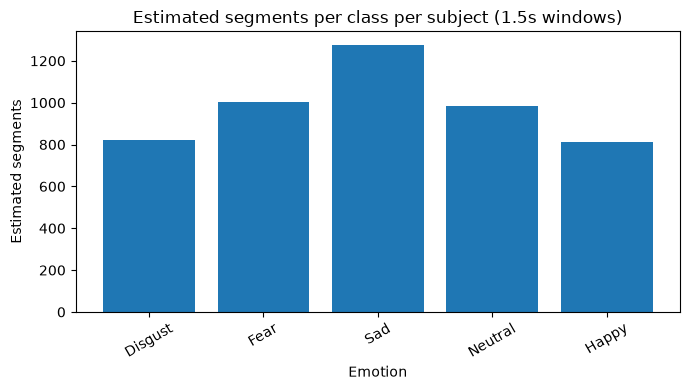

,label,emotion,estimated_segments,estimated_segments_for_3_subjects
0,0,Disgust,823,2469
1,1,Fear,1002,3006
2,2,Sad,1277,3831
3,3,Neutral,985,2955
4,4,Happy,810,2430


In [9]:
def build_trial_metadata(window_seconds: float = DEFAULT_WINDOW_SECONDS) -> pd.DataFrame:
    """Merge timestamps and emotion labels, then estimate number of segments per trial."""
    meta = timestamps_df.merge(emotion_df, on=["session", "trial"], how="inner")

    if len(meta) != len(timestamps_df):
        raise ValueError("Metadata merge failed: some timestamp rows have no emotion label.")

    meta["estimated_segments"] = np.floor(meta["duration_second"] / window_seconds).astype(int)
    return meta


trial_meta = build_trial_metadata(DEFAULT_WINDOW_SECONDS)
display(trial_meta.head(20))

summary = (
    trial_meta
    .groupby(["label", "emotion"], as_index=False)["estimated_segments"]
    .sum()
    .sort_values("label")
)

display(summary)

plt.figure(figsize=(7, 4))
plt.bar(summary["emotion"], summary["estimated_segments"])
plt.title(f"Estimated segments per class per subject ({DEFAULT_WINDOW_SECONDS}s windows)")
plt.xlabel("Emotion")
plt.ylabel("Estimated segments")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

expected_subjects = 3
summary_project_subset = summary.copy()
summary_project_subset["estimated_segments_for_3_subjects"] = (
    summary_project_subset["estimated_segments"] * expected_subjects
)
display(summary_project_subset)

## 5. Locate and parse `.cnt` files

Raw files are expected to be named as:

```text
subjectID_sessionID_date.cnt
```

Example:

```text
1_1_20180804.cnt
```

In [10]:
def parse_cnt_filename(path: Path) -> dict:
    """Extract subject, session and date from a SEED-V .cnt filename."""
    match = re.match(r"(?P<subject>\d+)_(?P<session>\d+)_(?P<date>\d+)\.cnt$", path.name)
    if match is None:
        raise ValueError(f"Unexpected .cnt filename format: {path.name}")

    return {
        "path": path,
        "subject": int(match.group("subject")),
        "session": int(match.group("session")),
        "date": match.group("date"),
    }


def list_cnt_files(eeg_raw_dir: Path = EEG_RAW_DIR) -> pd.DataFrame:
    """List available .cnt files and parse their metadata."""
    files = sorted(eeg_raw_dir.glob("*.cnt"))
    rows = []

    for file in files:
        try:
            rows.append(parse_cnt_filename(file))
        except ValueError as exc:
            warnings.warn(str(exc))

    return pd.DataFrame(rows)


cnt_files_df = list_cnt_files()

if cnt_files_df.empty:
    print(f"No .cnt files found in: {EEG_RAW_DIR.resolve()}")
    print("This is expected until the raw EEG files are added.")
else:
    display(cnt_files_df)
    print("Subjects:", sorted(cnt_files_df["subject"].unique()))
    print("Sessions:", sorted(cnt_files_df["session"].unique()))

,path,subject,session,date
0,EEG_raw\1_1_20180804.cnt,1,1,20180804
1,EEG_raw\1_2_20180810.cnt,1,2,20180810
2,EEG_raw\1_3_20180808.cnt,1,3,20180808
3,EEG_raw\2_1_20180416.cnt,2,1,20180416
4,EEG_raw\2_2_20180419.cnt,2,2,20180419
5,EEG_raw\2_3_20180425.cnt,2,3,20180425
6,EEG_raw\3_1_20180414.cnt,3,1,20180414
7,EEG_raw\3_2_20180419.cnt,3,2,20180419
8,EEG_raw\3_3_20180424.cnt,3,3,20180424


Subjects: [np.int64(1), np.int64(2), np.int64(3)]
Sessions: [np.int64(1), np.int64(2), np.int64(3)]


## 6. Load and preprocess one EEG recording

This block mirrors the lab idea based on MNE:

1. read raw EEG;
2. drop non-EEG channels;
3. apply a broadband filter;
4. optionally resample;
5. return the preprocessed `Raw` object.

For the SEED-V `.cnt` files we use `mne.io.read_raw_cnt`.

In [11]:
def load_and_preprocess_cnt(
    cnt_path: Path,
    drop_channels: list[str] = DROP_CHANNELS,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    resample_freq: float | None = RESAMPLE_FREQ,
):
    """Load a .cnt recording and apply basic EEG preprocessing."""
    if mne is None:
        raise ImportError("MNE is required. Install it with: pip install mne")

    with timed(f"load + preprocess {cnt_path.name}"):
        raw = mne.io.read_raw_cnt(cnt_path, preload=True, verbose="WARNING")

        existing_drop_channels = [ch for ch in drop_channels if ch in raw.ch_names]
        if existing_drop_channels:
            raw.drop_channels(existing_drop_channels)

        if low_freq is not None or high_freq is not None:
            raw.filter(l_freq=low_freq, h_freq=high_freq, verbose="WARNING")

        if resample_freq is not None:
            raw.resample(resample_freq, verbose="WARNING")

    return raw


# Preview one file without affecting dataset/model caches
if not cnt_files_df.empty:
    example_path = Path(cnt_files_df.iloc[0]["path"])
    raw_example = load_and_preprocess_cnt(example_path)

    print(raw_example)
    print("Sampling frequency:", raw_example.info["sfreq"])
    print("Number of channels:", len(raw_example.ch_names))
    print("Channels:", raw_example.ch_names)
else:
    print("Skipping raw loading preview: no .cnt files available yet.")

[START] load + preprocess 1_1_20180804.cnt
[END] load + preprocess 1_1_20180804.cnt - elapsed: 20.18s (0.34 min)
<RawCNT | 1_1_20180804.cnt, 62 x 844590 (3378.4 s), ~399.6 MiB, data loaded>
Sampling frequency: 250.0
Number of channels: 62
Channels: ['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2']


## 7. Extract trials and segment them into fixed-length windows

Each trial is first extracted using its start/end timestamp.

Then each trial is split into non-overlapping windows. The baseline is 1.5 seconds, as requested by the project.

In [12]:
def extract_trial_data(raw, start_second: float, end_second: float) -> np.ndarray:
    """Extract a trial from an MNE Raw object.

    Output shape:
        (n_channels, n_samples)
    """
    sfreq = raw.info["sfreq"]
    start_sample = int(round(start_second * sfreq))
    end_sample = int(round(end_second * sfreq))

    data = raw.get_data(start=start_sample, stop=end_sample)
    return data


def zscore_channels(segment: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Apply z-score normalization independently to each EEG channel."""
    mean = segment.mean(axis=1, keepdims=True)
    std = segment.std(axis=1, keepdims=True)
    return (segment - mean) / (std + eps)


def segment_trial(
    trial_data: np.ndarray,
    label: int,
    sfreq: float,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    normalize: bool = True,
):
    """Split a trial into non-overlapping EEG windows.

    Parameters
    ----------
    trial_data:
        EEG matrix with shape (n_channels, n_samples).
    label:
        Integer emotion label.
    sfreq:
        Sampling frequency.
    window_seconds:
        Duration of each segment in seconds.
    normalize:
        If True, z-score each segment channel-wise.

    Returns
    -------
    X:
        Array with shape (n_segments, n_channels, n_window_samples).
    y:
        Array with shape (n_segments,).
    """
    window_samples = int(round(window_seconds * sfreq))
    n_channels, n_samples = trial_data.shape
    n_segments = n_samples // window_samples

    X_segments = []
    y_segments = []

    for i in range(n_segments):
        start = i * window_samples
        end = start + window_samples
        segment = trial_data[:, start:end]

        if normalize:
            segment = zscore_channels(segment)

        X_segments.append(segment.astype(np.float32))
        y_segments.append(label)

    if not X_segments:
        return (
            np.empty((0, n_channels, window_samples), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
        )

    return np.stack(X_segments), np.array(y_segments, dtype=np.int64)


# Synthetic test to verify shapes
synthetic_trial = np.random.randn(62, 10_000)  # 62 channels, 10 seconds at 1000 Hz
X_syn, y_syn = segment_trial(synthetic_trial, label=4, sfreq=1000, window_seconds=1.5)

print("Synthetic segmented X shape:", X_syn.shape)
print("Synthetic y shape:", y_syn.shape)

Synthetic segmented X shape: (6, 62, 1500)
Synthetic y shape: (6,)


## 8. Build or load the segmented dataset

This version caches the expensive `.cnt → filtered raw → segmented windows` step.

For each experimental configuration, the notebook creates a separate folder:

```text
outputs/datasets/win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz/
├── recordings/
│   ├── 1_1_20180804_segments.npz
│   ├── ...
├── dataset.npz
├── segment_meta.csv
└── config.json
```

The first run is slow because it reads, filters and segments every `.cnt` file. Later runs can load `dataset.npz` directly.

In [13]:
def recording_cache_path(cache_dir: Path, cnt_path: Path) -> Path:
    """Return the per-recording cache path for a .cnt file."""
    return cache_dir / "recordings" / f"{cnt_path.stem}_segments.npz"


def save_config(cache_dir: Path, config: dict):
    """Save preprocessing/segmentation configuration for reproducibility."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    with (cache_dir / "config.json").open("w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)


def load_segmented_dataset_from_cache(cache_dir: Path):
    """Load complete segmented dataset from cache."""
    dataset_path = cache_dir / "dataset.npz"
    meta_path = cache_dir / "segment_meta.csv"

    if not dataset_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Dataset cache not found in {cache_dir}")

    with timed(f"load cached segmented dataset from {cache_dir}"):
        data = np.load(dataset_path)
        X = data["X"]
        y = data["y"]
        segment_meta = pd.read_csv(meta_path)

    return X, y, segment_meta


def save_segmented_dataset_to_cache(cache_dir: Path, X: np.ndarray, y: np.ndarray, segment_meta: pd.DataFrame):
    """Save complete segmented dataset to cache."""
    cache_dir.mkdir(parents=True, exist_ok=True)

    with timed(f"save segmented dataset to {cache_dir}"):
        np.savez_compressed(cache_dir / "dataset.npz", X=X, y=y)
        segment_meta.to_csv(cache_dir / "segment_meta.csv", index=False)


def build_segmented_dataset(
    cnt_files: pd.DataFrame,
    trial_metadata: pd.DataFrame,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    use_cache: bool = USE_DATASET_CACHE,
    force_rebuild: bool = FORCE_REBUILD_DATASET,
    save_cache: bool = SAVE_DATASET_CACHE,
):
    """Build or load the segment-level EEG dataset.

    The function uses two cache levels:
    1. per-recording cache: one `.npz` for each `.cnt` file;
    2. full dataset cache: combined `X`, `y`, and metadata.
    """
    if cnt_files.empty:
        raise ValueError("No .cnt files available. Add raw recordings to EEG_RAW_DIR first.")

    cache_dir = dataset_cache_dir(window_seconds, resample_freq, low_freq, high_freq)
    recordings_dir = cache_dir / "recordings"
    recordings_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "window_seconds": window_seconds,
        "resample_freq": resample_freq,
        "low_freq": low_freq,
        "high_freq": high_freq,
        "drop_channels": DROP_CHANNELS,
        "random_state": RANDOM_STATE,
    }
    save_config(cache_dir, config)

    dataset_path = cache_dir / "dataset.npz"
    meta_path = cache_dir / "segment_meta.csv"

    if use_cache and not force_rebuild and dataset_path.exists() and meta_path.exists():
        return load_segmented_dataset_from_cache(cache_dir)

    all_X = []
    all_y = []
    all_meta = []

    with timed(f"build segmented dataset [{experiment_tag(window_seconds, resample_freq, low_freq, high_freq)}]"):
        for _, file_row in cnt_files.iterrows():
            cnt_path = Path(file_row["path"])
            subject = int(file_row["subject"])
            session = int(file_row["session"])
            rec_cache = recording_cache_path(cache_dir, cnt_path)

            if use_cache and not force_rebuild and rec_cache.exists():
                with timed(f"load cached recording {rec_cache.name}"):
                    rec_data = np.load(rec_cache, allow_pickle=True)
                    X_recording = rec_data["X"]
                    y_recording = rec_data["y"]
                    meta_recording = pd.DataFrame(rec_data["meta"].tolist())
            else:
                print(f"Processing subject={subject}, session={session}, file={cnt_path.name}")

                raw = load_and_preprocess_cnt(
                    cnt_path,
                    low_freq=low_freq,
                    high_freq=high_freq,
                    resample_freq=resample_freq,
                )
                sfreq = float(raw.info["sfreq"])

                session_trials = trial_metadata[trial_metadata["session"] == session].copy()

                X_parts = []
                y_parts = []
                meta_rows = []

                with timed(f"segment {cnt_path.name}"):
                    for _, trial_row in session_trials.iterrows():
                        trial_id = int(trial_row["trial"])
                        label = int(trial_row["label"])
                        emotion = trial_row["emotion"]

                        trial_data = extract_trial_data(
                            raw,
                            start_second=float(trial_row["start_second"]),
                            end_second=float(trial_row["end_second"]),
                        )

                        X_trial, y_trial = segment_trial(
                            trial_data,
                            label=label,
                            sfreq=sfreq,
                            window_seconds=window_seconds,
                            normalize=True,
                        )

                        X_parts.append(X_trial)
                        y_parts.append(y_trial)

                        for segment_idx in range(len(y_trial)):
                            meta_rows.append({
                                "subject": subject,
                                "session": session,
                                "trial": trial_id,
                                "segment": segment_idx,
                                "emotion": emotion,
                                "label": label,
                                "source_file": cnt_path.name,
                                "sfreq": sfreq,
                                "window_seconds": window_seconds,
                                "resample_freq": resample_freq,
                                "low_freq": low_freq,
                                "high_freq": high_freq,
                            })

                X_recording = np.concatenate(X_parts, axis=0)
                y_recording = np.concatenate(y_parts, axis=0)
                meta_recording = pd.DataFrame(meta_rows)

                if save_cache:
                    with timed(f"save cached recording {rec_cache.name}"):
                        np.savez_compressed(
                            rec_cache,
                            X=X_recording,
                            y=y_recording,
                            meta=meta_recording.to_dict("records"),
                        )

            all_X.append(X_recording)
            all_y.append(y_recording)
            all_meta.append(meta_recording)

        X = np.concatenate(all_X, axis=0)
        y = np.concatenate(all_y, axis=0)
        segment_meta = pd.concat(all_meta, ignore_index=True)

    if save_cache:
        save_segmented_dataset_to_cache(cache_dir, X, y, segment_meta)

    return X, y, segment_meta


trial_meta = build_trial_metadata(DEFAULT_WINDOW_SECONDS)

X, y, segment_meta = build_segmented_dataset(
    cnt_files_df,
    trial_meta,
    window_seconds=DEFAULT_WINDOW_SECONDS,
    resample_freq=RESAMPLE_FREQ,
    low_freq=LOW_FREQ,
    high_freq=HIGH_FREQ,
    use_cache=USE_DATASET_CACHE,
    force_rebuild=FORCE_REBUILD_DATASET,
    save_cache=SAVE_DATASET_CACHE,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Dataset cache folder:", dataset_cache_dir(DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ).resolve())
display(segment_meta.head())
display(segment_meta["emotion"].value_counts())

[START] load cached segmented dataset from outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz
[END] load cached segmented dataset from outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz - elapsed: 5.84s (0.10 min)
X shape: (14691, 62, 375)
y shape: (14691,)
Dataset cache folder: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz


,subject,session,trial,segment,emotion,label,source_file,sfreq,window_seconds,resample_freq,low_freq,high_freq
0,1,1,1,0,Happy,4,1_1_20180804.cnt,250.0,1.5,250.0,1.0,50.0
1,1,1,1,1,Happy,4,1_1_20180804.cnt,250.0,1.5,250.0,1.0,50.0
2,1,1,1,2,Happy,4,1_1_20180804.cnt,250.0,1.5,250.0,1.0,50.0
3,1,1,1,3,Happy,4,1_1_20180804.cnt,250.0,1.5,250.0,1.0,50.0
4,1,1,1,4,Happy,4,1_1_20180804.cnt,250.0,1.5,250.0,1.0,50.0


emotion
Sad        3831
Fear       3006
Neutral    2955
Disgust    2469
Happy      2430
Name: count, dtype: int64

## 9. Train / validation / test split

The required split is:

- 70% training
- 15% validation
- 15% testing

The first baseline uses stratified random splitting. Later we can add subject-wise/session-wise splitting to analyze inter-subject variability and possible temporal leakage.

In [14]:
def split_train_val_test(
    X: np.ndarray,
    y: np.ndarray,
    segment_meta: pd.DataFrame | None = None,
    random_state: int = RANDOM_STATE,
):
    """Create a 70/15/15 stratified split."""
    X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
        X,
        y,
        np.arange(len(y)),
        test_size=0.30,
        random_state=random_state,
        stratify=y,
        shuffle=True,
    )

    X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
        X_temp,
        y_temp,
        idx_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=y_temp,
        shuffle=True,
    )

    meta_splits = None
    if segment_meta is not None:
        meta_splits = {
            "train": segment_meta.iloc[idx_train].reset_index(drop=True),
            "val": segment_meta.iloc[idx_val].reset_index(drop=True),
            "test": segment_meta.iloc[idx_test].reset_index(drop=True),
        }

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), meta_splits


def print_split_summary(y_train, y_val, y_test):
    """Print class distributions for the three splits."""
    for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
        counts = pd.Series(labels).value_counts().sort_index()
        print(f"\n{name.upper()} split ({len(labels)} samples)")
        for label_id, count in counts.items():
            print(f"  {ID_TO_LABEL[int(label_id)]:8s}: {count}")


# Run after building X/y:
(X_train, y_train), (X_val, y_val), (X_test, y_test), meta_splits = split_train_val_test(X, y, segment_meta)
print_split_summary(y_train, y_val, y_test)


TRAIN split (10283 samples)
  Disgust : 1728
  Fear    : 2104
  Sad     : 2682
  Neutral : 2068
  Happy   : 1701

VAL split (2204 samples)
  Disgust : 370
  Fear    : 451
  Sad     : 574
  Neutral : 444
  Happy   : 365

TEST split (2204 samples)
  Disgust : 371
  Fear    : 451
  Sad     : 575
  Neutral : 443
  Happy   : 364


## 10. Prepare tensors for 1D-CNN and 2D-CNN

The raw segment shape from the dataset builder is:

```text
(n_segments, n_channels, n_samples)
```

For the 1D-CNN we use:

```text
(n_segments, n_samples, n_channels)
```

For the 2D-CNN baseline we use a simple channel-time image:

```text
(n_segments, n_channels, n_samples, 1)
```

In [15]:
def to_1d_cnn_input(X: np.ndarray) -> np.ndarray:
    """Convert segments to Conv1D input: (batch, time, channels)."""
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


def to_2d_cnn_input(X: np.ndarray) -> np.ndarray:
    """Convert segments to Conv2D input: (batch, channels, time, 1)."""
    return X[..., np.newaxis].astype(np.float32)


# Example:
X_train_1d = to_1d_cnn_input(X_train)
X_val_1d = to_1d_cnn_input(X_val)
X_test_1d = to_1d_cnn_input(X_test)

X_train_2d = to_2d_cnn_input(X_train)
X_val_2d = to_2d_cnn_input(X_val)
X_test_2d = to_2d_cnn_input(X_test)

print("1D input:", X_train_1d.shape)
print("2D input:", X_train_2d.shape)

1D input: (10283, 375, 62)
2D input: (10283, 62, 375, 1)


## Model training, cache and experiments

The following blocks add the missing project parts: 1D-CNN, 2D-CNN, train/load flags, evaluation, result tables and configurable window/resampling experiments.

## 11. TensorFlow/Keras setup

From this point onward we train the two required deep-learning recognizers:

- **1D-CNN**: temporal convolution over EEG time series.
- **2D-CNN**: convolution over a simple channel-time matrix.

The labels are integer encoded, so the loss is `sparse_categorical_crossentropy`.

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
tf.keras.utils.set_random_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("Number of classes:", N_CLASSES)
print("Class names:", CLASS_NAMES)

TensorFlow version: 2.21.0
Number of classes: 5
Class names: ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']


## 12. Utility functions for class imbalance, plots and file saving

The dataset is not perfectly balanced, so the training function can optionally use class weights.

Training curves are saved under `outputs/plots/seed_<RANDOM_STATE>/` so that experiments with the same variables but different seeds remain separated.


In [17]:
def get_class_weights(y: np.ndarray) -> dict[int, float]:
    """Compute class weights for sparse integer labels."""
    classes = np.unique(y)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y,
    )
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}


def save_figure(fig, path: Path, dpi: int = 150) -> Path:
    """Save a matplotlib figure and return the final path."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved plot: {path.resolve()}")
    return path


def plot_training_history(
    history,
    title: str = "Training history",
    output_tag: str | None = None,
    save_outputs: bool = True,
    show: bool = True,
) -> dict[str, Path]:
    """Plot and optionally save loss and accuracy curves for one training run."""
    hist = pd.DataFrame(history.history)
    saved_paths = {}

    if output_tag is None:
        output_tag = _safe_name_token(title)

    fig_loss, ax_loss = plt.subplots(figsize=(7, 4))
    ax_loss.plot(hist["loss"], label="train loss")
    ax_loss.plot(hist["val_loss"], label="val loss")
    ax_loss.set_title(f"{title} - loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    fig_loss.tight_layout()

    if save_outputs:
        saved_paths["loss_plot"] = save_figure(
            fig_loss,
            PLOTS_SEED_DIR / f"{output_tag}_loss.png",
        )

    if show:
        plt.show()
    else:
        plt.close(fig_loss)

    if "accuracy" in hist and "val_accuracy" in hist:
        fig_acc, ax_acc = plt.subplots(figsize=(7, 4))
        ax_acc.plot(hist["accuracy"], label="train accuracy")
        ax_acc.plot(hist["val_accuracy"], label="val accuracy")
        ax_acc.set_title(f"{title} - accuracy")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.legend()
        fig_acc.tight_layout()

        if save_outputs:
            saved_paths["accuracy_plot"] = save_figure(
                fig_acc,
                PLOTS_SEED_DIR / f"{output_tag}_accuracy.png",
            )

        if show:
            plt.show()
        else:
            plt.close(fig_acc)

    return saved_paths


def summarize_dataset_shapes():
    """Print the main tensors if they already exist in the notebook."""
    names = [
        "X_train", "X_val", "X_test",
        "X_train_1d", "X_val_1d", "X_test_1d",
        "X_train_2d", "X_val_2d", "X_test_2d",
    ]

    for name in names:
        if name in globals():
            print(f"{name:12s}: {globals()[name].shape}")

    if "y_train" in globals():
        print("\nClass weights:", get_class_weights(y_train))


summarize_dataset_shapes()


X_train     : (10283, 62, 375)
X_val       : (2204, 62, 375)
X_test      : (2204, 62, 375)
X_train_1d  : (10283, 375, 62)
X_val_1d    : (2204, 375, 62)
X_test_1d   : (2204, 375, 62)
X_train_2d  : (10283, 62, 375, 1)
X_val_2d    : (2204, 62, 375, 1)
X_test_2d   : (2204, 62, 375, 1)

Class weights: {0: 1.190162037037037, 1: 0.9774714828897338, 2: 0.7668158090976883, 3: 0.9944874274661508, 4: 1.2090534979423868}


## 13. 1D-CNN recognizer

Input shape:

```text
(batch, time_samples, channels)
```

This model is meant to learn temporal patterns directly from the EEG sequence.

In [18]:
def build_1d_cnn(
    input_shape: tuple,
    n_classes: int = N_CLASSES,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    """Build a baseline 1D-CNN for EEG emotion recognition."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="EEG_1D_CNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


if "X_train_1d" in globals():
    model_1d_preview = build_1d_cnn(input_shape=X_train_1d.shape[1:])
    model_1d_preview.summary()
else:
    print("X_train_1d is not available yet. Run the dataset and split cells first.")

Model: "EEG_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 375, 62)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 375, 32)        │        13,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 375, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 93, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,405 (228.14 KB)

 Trainable params: 57,957 (226.39 KB)

 Non-trainable params: 448 (1.75 KB)

## 14. 2D-CNN recognizer

Input shape:

```text
(batch, channels, time_samples, 1)
```

This is a simple spatial-temporal baseline: each EEG segment is treated as a channel-time image.

In [19]:
def build_2d_cnn(
    input_shape: tuple,
    n_classes: int = N_CLASSES,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    """Build a baseline 2D-CNN for channel-time EEG matrices."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=(3, 7), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(1, 2))(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, kernel_size=(3, 5), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="EEG_2D_CNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


if "X_train_2d" in globals():
    model_2d_preview = build_2d_cnn(input_shape=X_train_2d.shape[1:])
    model_2d_preview.summary()
else:
    print("X_train_2d is not available yet. Run the dataset and split cells first.")

Model: "EEG_2D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 62, 375, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 375, 32)    │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 375, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 187, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 62, 187, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 187, 64)    │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 187, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 93, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 31, 93, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 93, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 31, 93, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,821 (448.52 KB)

 Trainable params: 114,373 (446.77 KB)

 Non-trainable params: 448 (1.75 KB)

## 15. Training, loading and evaluation functions

Models are trained only when requested, or when no saved `.keras` model exists for the current configuration and seed.

Evaluation outputs are saved under `outputs/`:
- `outputs/models/seed_<RANDOM_STATE>/...` for trained models and histories;
- `outputs/plots/seed_<RANDOM_STATE>/...` for loss/accuracy plots;
- `outputs/confusion_matrices/seed_<RANDOM_STATE>/...` for confusion matrices;
- `outputs/scores/seed_<RANDOM_STATE>/...` for classification reports, prediction scores and JSON summaries.

The timing messages printed by `timed(...)` help identify the bottleneck: `.cnt` loading/filtering, segmentation, model training, model loading, or evaluation.


In [20]:
def train_eeg_model(
    model: tf.keras.Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE,
    patience: int = PATIENCE,
    use_class_weights: bool = USE_CLASS_WEIGHTS,
):
    """Train an EEG model using validation monitoring."""
    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    class_weight = get_class_weights(y_train) if use_class_weights else None

    with timed(f"train {model.name}"):
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=cb,
            class_weight=class_weight,
            verbose=1,
        )

    return history


def model_path(
    model_kind: str,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    random_state: int = RANDOM_STATE,
) -> Path:
    """Return the Keras model path for a specific experiment and seed."""
    folder = model_cache_dir(window_seconds, resample_freq, low_freq, high_freq, random_state)
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"model_{_safe_name_token(model_kind)}.keras"


def history_path(
    model_kind: str,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    random_state: int = RANDOM_STATE,
) -> Path:
    """Return CSV path for a model training history."""
    folder = model_cache_dir(window_seconds, resample_freq, low_freq, high_freq, random_state)
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"history_{_safe_name_token(model_kind)}.csv"


def train_or_load_eeg_model(
    model_kind: str,
    build_fn,
    input_shape: tuple,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
    train_model: bool = False,
    force_retrain: bool = False,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE,
    patience: int = PATIENCE,
    random_state: int = RANDOM_STATE,
):
    """Train a model only when requested or when no saved model exists."""
    path = model_path(model_kind, window_seconds, resample_freq, low_freq, high_freq, random_state)
    hist_path = history_path(model_kind, window_seconds, resample_freq, low_freq, high_freq, random_state)
    should_train = train_model or force_retrain or not path.exists()

    if should_train:
        print(f"Training {model_kind}. Target path: {path}")
        model = build_fn(input_shape=input_shape)
        history = train_eeg_model(
            model,
            X_train,
            y_train,
            X_val,
            y_val,
            epochs=epochs,
            batch_size=batch_size,
            patience=patience,
            use_class_weights=USE_CLASS_WEIGHTS,
        )
        with timed(f"save model {path.name}"):
            model.save(path)
        pd.DataFrame(history.history).to_csv(hist_path, index=False)
        print("Saved training history:", hist_path.resolve())
        return model, history, True

    print(f"Loading cached {model_kind} model from: {path}")
    with timed(f"load model {path.name}"):
        model = tf.keras.models.load_model(path)
    return model, None, False


def save_evaluation_outputs(
    model_name: str,
    output_tag: str,
    y_test: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    test_loss: float,
    test_accuracy: float,
    cm: np.ndarray,
) -> dict[str, Path]:
    """Save scores, predictions and confusion matrices for one evaluation run."""
    output_tag = _safe_name_token(output_tag)
    saved_paths = {}

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report_dict).T
    report_path = SCORES_SEED_DIR / f"{output_tag}_classification_report.csv"
    report_df.to_csv(report_path)
    saved_paths["classification_report"] = report_path
    print("Saved classification report:", report_path.resolve())

    predictions_df = pd.DataFrame({
        "sample_index": np.arange(len(y_test)),
        "y_true": y_test.astype(int),
        "y_true_label": [ID_TO_LABEL[int(v)] for v in y_test],
        "y_pred": y_pred.astype(int),
        "y_pred_label": [ID_TO_LABEL[int(v)] for v in y_pred],
        "correct": y_test.astype(int) == y_pred.astype(int),
    })
    for class_id, class_name in enumerate(CLASS_NAMES):
        predictions_df[f"score_{_safe_name_token(class_name)}"] = y_proba[:, class_id]

    predictions_path = SCORES_SEED_DIR / f"{output_tag}_predictions.csv"
    predictions_df.to_csv(predictions_path, index=False)
    saved_paths["predictions"] = predictions_path
    print("Saved prediction scores:", predictions_path.resolve())

    cm_path = CONFUSION_MATRICES_SEED_DIR / f"{output_tag}_confusion_matrix_counts.csv"
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_df.to_csv(cm_path)
    saved_paths["confusion_matrix_counts"] = cm_path
    print("Saved confusion matrix counts:", cm_path.resolve())

    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    cm_norm_path = CONFUSION_MATRICES_SEED_DIR / f"{output_tag}_confusion_matrix_normalized.csv"
    pd.DataFrame(cm_norm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(cm_norm_path)
    saved_paths["confusion_matrix_normalized"] = cm_norm_path
    print("Saved normalized confusion matrix:", cm_norm_path.resolve())

    summary = {
        "model": model_name,
        "random_state": int(RANDOM_STATE),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "n_test_samples": int(len(y_test)),
        "classification_report_csv": str(report_path),
        "predictions_csv": str(predictions_path),
        "confusion_matrix_counts_csv": str(cm_path),
        "confusion_matrix_normalized_csv": str(cm_norm_path),
    }
    summary_path = SCORES_SEED_DIR / f"{output_tag}_summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    saved_paths["summary"] = summary_path
    print("Saved score summary:", summary_path.resolve())

    return saved_paths


def evaluate_eeg_model(
    model: tf.keras.Model,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_name: str,
    normalize_cm: bool = False,
    output_tag: str | None = None,
    save_outputs: bool = True,
) -> dict:
    """Evaluate a trained model on the test set, save scores and plot its confusion matrix."""
    if output_tag is None:
        output_tag = _safe_name_token(model_name)

    with timed(f"evaluate {model_name}"):
        test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
        y_proba = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_proba, axis=1)

    print(f"{model_name} test loss: {test_loss:.4f}")
    print(f"{model_name} test accuracy: {test_accuracy:.4f}\n")

    print(classification_report(
        y_test,
        y_pred,
        labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES)))

    if normalize_cm:
        cm_display = confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES)), normalize="true")
        values_format = ".2f"
        title_suffix = "normalized"
    else:
        cm_display = cm
        values_format = "d"
        title_suffix = "counts"

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_display, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, xticks_rotation=45, values_format=values_format)
    ax.set_title(f"{model_name} confusion matrix ({title_suffix})")
    fig.tight_layout()

    output_paths = {}
    if save_outputs:
        output_tag = _safe_name_token(output_tag)
        output_paths = save_evaluation_outputs(
            model_name=model_name,
            output_tag=output_tag,
            y_test=y_test,
            y_pred=y_pred,
            y_proba=y_proba,
            test_loss=test_loss,
            test_accuracy=test_accuracy,
            cm=cm,
        )
        output_paths["confusion_matrix_plot"] = save_figure(
            fig,
            CONFUSION_MATRICES_SEED_DIR / f"{output_tag}_confusion_matrix_{title_suffix}.png",
        )

    plt.show()

    return {
        "model": model_name,
        "random_state": int(RANDOM_STATE),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "confusion_matrix": cm,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "output_tag": output_tag,
        "output_paths": output_paths,
    }


## 16. Baseline experiment: 1.5-second windows

The flags in section 1 control whether models are trained or loaded.

Typical workflow:

```python
TRAIN_BASELINE_1D = True   # first run, then set False
TRAIN_BASELINE_2D = True   # first run, then set False
```

If the `.keras` file already exists and the training flag is `False`, the model is loaded and only evaluation/plots are recomputed.

In [21]:
baseline_results = []

if RUN_BASELINE_1D:
    model_1d, history_1d, trained_1d = train_or_load_eeg_model(
        model_kind="1d_cnn",
        build_fn=build_1d_cnn,
        input_shape=X_train_1d.shape[1:],
        X_train=X_train_1d,
        y_train=y_train,
        X_val=X_val_1d,
        y_val=y_val,
        window_seconds=DEFAULT_WINDOW_SECONDS,
        resample_freq=RESAMPLE_FREQ,
        train_model=TRAIN_BASELINE_1D,
        force_retrain=FORCE_RETRAIN_BASELINE_1D,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patience=PATIENCE,
    )

    output_tag_1d = run_output_tag("1d_cnn", DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ)

    if history_1d is not None:
        plot_training_history(history_1d, title="1D-CNN", output_tag=output_tag_1d)

    result_1d = evaluate_eeg_model(
        model_1d,
        X_test_1d,
        y_test,
        model_name="1D-CNN",
        output_tag=output_tag_1d,
    )
    result_1d.update({
        "window_seconds": DEFAULT_WINDOW_SECONDS,
        "resample_freq": RESAMPLE_FREQ,
        "trained_in_this_run": trained_1d,
    })
    baseline_results.append(result_1d)
else:
    print("RUN_BASELINE_1D is False: skipping 1D-CNN baseline.")

RUN_BASELINE_1D is False: skipping 1D-CNN baseline.


In [22]:
if RUN_BASELINE_2D:
    model_2d, history_2d, trained_2d = train_or_load_eeg_model(
        model_kind="2d_cnn",
        build_fn=build_2d_cnn,
        input_shape=X_train_2d.shape[1:],
        X_train=X_train_2d,
        y_train=y_train,
        X_val=X_val_2d,
        y_val=y_val,
        window_seconds=DEFAULT_WINDOW_SECONDS,
        resample_freq=RESAMPLE_FREQ,
        train_model=TRAIN_BASELINE_2D,
        force_retrain=FORCE_RETRAIN_BASELINE_2D,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patience=PATIENCE,
    )

    output_tag_2d = run_output_tag("2d_cnn", DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ)

    if history_2d is not None:
        plot_training_history(history_2d, title="2D-CNN", output_tag=output_tag_2d)

    result_2d = evaluate_eeg_model(
        model_2d,
        X_test_2d,
        y_test,
        model_name="2D-CNN",
        output_tag=output_tag_2d,
    )
    result_2d.update({
        "window_seconds": DEFAULT_WINDOW_SECONDS,
        "resample_freq": RESAMPLE_FREQ,
        "trained_in_this_run": trained_2d,
    })
    baseline_results.append(result_2d)
else:
    print("RUN_BASELINE_2D is False: skipping 2D-CNN baseline.")

RUN_BASELINE_2D is False: skipping 2D-CNN baseline.


## 17. Baseline comparison table

This table is useful for the presentation: it gives a compact comparison between 1D-CNN and 2D-CNN.

In [23]:
if baseline_results:
    baseline_table = pd.DataFrame([
        {
            "model": result["model"],
            "window_seconds": result.get("window_seconds", DEFAULT_WINDOW_SECONDS),
            "resample_freq": result.get("resample_freq", RESAMPLE_FREQ),
            "random_state": result.get("random_state", RANDOM_STATE),
            "test_loss": result["test_loss"],
            "test_accuracy": result["test_accuracy"],
            "trained_in_this_run": result.get("trained_in_this_run", None),
        }
        for result in baseline_results
    ])

    display(baseline_table.sort_values("test_accuracy", ascending=False))

    baseline_plot_tag = run_output_tag("baseline_accuracy_comparison", DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(baseline_table["model"], baseline_table["test_accuracy"])
    ax.set_ylim(0, 1)
    ax.set_title(f"Baseline test accuracy ({DEFAULT_WINDOW_SECONDS}s, resample={RESAMPLE_FREQ}, {seed_tag()})")
    ax.set_xlabel("Model")
    ax.set_ylabel("Test accuracy")
    fig.tight_layout()
    save_figure(fig, PLOTS_SEED_DIR / f"{baseline_plot_tag}.png")
    plt.show()
else:
    baseline_table = pd.DataFrame()
    print("No baseline models were run. Enable RUN_BASELINE_1D and/or RUN_BASELINE_2D.")


No baseline models were run. Enable RUN_BASELINE_1D and/or RUN_BASELINE_2D.


## 18. Save result tables

Models are saved automatically by `train_or_load_eeg_model()` when they are trained. This cell only saves result tables.

In [24]:
if not baseline_table.empty:
    baseline_results_path = RESULTS_SEED_DIR / f"baseline_results_{experiment_tag(DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ)}_{seed_tag()}.csv"
    baseline_table.to_csv(baseline_results_path, index=False)
    print("Saved baseline table:", baseline_results_path.resolve())

print("Dataset cache root:", DATASET_CACHE_ROOT.resolve())
print("Model cache root:", MODEL_CACHE_ROOT.resolve())
print("Results root:", RESULTS_DIR.resolve())
print("Results for this seed:", RESULTS_SEED_DIR.resolve())
print("Plots for this seed:", PLOTS_SEED_DIR.resolve())
print("Scores for this seed:", SCORES_SEED_DIR.resolve())


Dataset cache root: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\datasets
Model cache root: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\models
Results root: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\results


## 19. Open problem: effect of EEG window duration and resampling

The project asks to explore how sample duration affects recognition performance. Suggested windows:

```text
1.0 s, 1.5 s, 2.0 s
```

The additional resampling-frequency experiment is optional. It is useful if preprocessing/training time is too high or if you want to discuss computational cost.

In [25]:
def prepare_dataset_for_config(
    window_seconds: float,
    resample_freq: float | None = RESAMPLE_FREQ,
    low_freq: float | None = LOW_FREQ,
    high_freq: float | None = HIGH_FREQ,
):
    """Build/load dataset, split it, and prepare 1D/2D tensors for a configuration."""
    trial_meta_window = build_trial_metadata(window_seconds)
    X_window, y_window, segment_meta_window = build_segmented_dataset(
        cnt_files_df,
        trial_meta_window,
        window_seconds=window_seconds,
        resample_freq=resample_freq,
        low_freq=low_freq,
        high_freq=high_freq,
        use_cache=USE_DATASET_CACHE,
        force_rebuild=FORCE_REBUILD_DATASET,
        save_cache=SAVE_DATASET_CACHE,
    )

    (X_train_w, y_train_w), (X_val_w, y_val_w), (X_test_w, y_test_w), meta_splits_w = split_train_val_test(
        X_window,
        y_window,
        segment_meta_window,
    )

    return {
        "window_seconds": window_seconds,
        "resample_freq": resample_freq,
        "X": X_window,
        "y": y_window,
        "segment_meta": segment_meta_window,
        "X_train": X_train_w,
        "y_train": y_train_w,
        "X_val": X_val_w,
        "y_val": y_val_w,
        "X_test": X_test_w,
        "y_test": y_test_w,
        "X_train_1d": to_1d_cnn_input(X_train_w),
        "X_val_1d": to_1d_cnn_input(X_val_w),
        "X_test_1d": to_1d_cnn_input(X_test_w),
        "X_train_2d": to_2d_cnn_input(X_train_w),
        "X_val_2d": to_2d_cnn_input(X_val_w),
        "X_test_2d": to_2d_cnn_input(X_test_w),
        "meta_splits": meta_splits_w,
    }


def run_config_experiment(
    window_seconds: float,
    resample_freq: float | None = RESAMPLE_FREQ,
    epochs: int = EXPERIMENT_EPOCHS,
    batch_size: int = BATCH_SIZE,
    patience: int = EXPERIMENT_PATIENCE,
    train_1d: bool = True,
    train_2d: bool = True,
    force_retrain: bool = False,
):
    """Train/load and evaluate the 1D-CNN and/or 2D-CNN for one configuration."""
    data = prepare_dataset_for_config(window_seconds=window_seconds, resample_freq=resample_freq)

    print("\nConfiguration:", experiment_tag(window_seconds, resample_freq, LOW_FREQ, HIGH_FREQ))
    print("X:", data["X"].shape)
    print("y:", data["y"].shape)
    print("Dataset cache:", dataset_cache_dir(window_seconds, resample_freq, LOW_FREQ, HIGH_FREQ).resolve())
    print_split_summary(data["y_train"], data["y_val"], data["y_test"])

    rows = []
    models_out = {}

    if train_1d:
        model, history, did_train = train_or_load_eeg_model(
            model_kind="1d_cnn",
            build_fn=build_1d_cnn,
            input_shape=data["X_train_1d"].shape[1:],
            X_train=data["X_train_1d"],
            y_train=data["y_train"],
            X_val=data["X_val_1d"],
            y_val=data["y_val"],
            window_seconds=window_seconds,
            resample_freq=resample_freq,
            train_model=True,
            force_retrain=force_retrain,
            epochs=epochs,
            batch_size=batch_size,
            patience=patience,
        )
        output_tag_1d = run_output_tag("1d_cnn", window_seconds, resample_freq, LOW_FREQ, HIGH_FREQ)
        if history is not None:
            plot_training_history(
                history,
                title=f"1D-CNN {window_seconds}s, rs={resample_freq}",
                output_tag=output_tag_1d,
            )
        result = evaluate_eeg_model(
            model,
            data["X_test_1d"],
            data["y_test"],
            model_name=f"1D-CNN {window_seconds}s rs={resample_freq}",
            output_tag=output_tag_1d,
        )
        rows.append({
            "window_seconds": window_seconds,
            "resample_freq": resample_freq,
            "model": "1D-CNN",
            "random_state": int(RANDOM_STATE),
            "test_loss": result["test_loss"],
            "test_accuracy": result["test_accuracy"],
            "n_samples": len(data["y"]),
            "trained_in_this_run": did_train,
        })
        models_out["1d"] = model

    if train_2d:
        model, history, did_train = train_or_load_eeg_model(
            model_kind="2d_cnn",
            build_fn=build_2d_cnn,
            input_shape=data["X_train_2d"].shape[1:],
            X_train=data["X_train_2d"],
            y_train=data["y_train"],
            X_val=data["X_val_2d"],
            y_val=data["y_val"],
            window_seconds=window_seconds,
            resample_freq=resample_freq,
            train_model=True,
            force_retrain=force_retrain,
            epochs=epochs,
            batch_size=batch_size,
            patience=patience,
        )
        output_tag_2d = run_output_tag("2d_cnn", window_seconds, resample_freq, LOW_FREQ, HIGH_FREQ)
        if history is not None:
            plot_training_history(
                history,
                title=f"2D-CNN {window_seconds}s, rs={resample_freq}",
                output_tag=output_tag_2d,
            )
        result = evaluate_eeg_model(
            model,
            data["X_test_2d"],
            data["y_test"],
            model_name=f"2D-CNN {window_seconds}s rs={resample_freq}",
            output_tag=output_tag_2d,
        )
        rows.append({
            "window_seconds": window_seconds,
            "resample_freq": resample_freq,
            "model": "2D-CNN",
            "random_state": int(RANDOM_STATE),
            "test_loss": result["test_loss"],
            "test_accuracy": result["test_accuracy"],
            "n_samples": len(data["y"]),
            "trained_in_this_run": did_train,
        })
        models_out["2d"] = model

    return pd.DataFrame(rows), models_out

### Run window-duration and resampling experiments

Both blocks are protected by flags. This avoids accidentally launching expensive jobs.

[START] build segmented dataset [win_1p0s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz]
Processing subject=1, session=1, file=1_1_20180804.cnt
[START] load + preprocess 1_1_20180804.cnt
[END] load + preprocess 1_1_20180804.cnt - elapsed: 19.00s (0.32 min)
[START] segment 1_1_20180804.cnt
[END] segment 1_1_20180804.cnt - elapsed: 0.50s (0.01 min)
[START] save cached recording 1_1_20180804_segments.npz
[END] save cached recording 1_1_20180804_segments.npz - elapsed: 7.26s (0.12 min)
Processing subject=1, session=2, file=1_2_20180810.cnt
[START] load + preprocess 1_2_20180810.cnt
[END] load + preprocess 1_2_20180810.cnt - elapsed: 17.74s (0.30 min)
[START] segment 1_2_20180810.cnt
[END] segment 1_2_20180810.cnt - elapsed: 0.39s (0.01 min)
[START] save cached recording 1_2_20180810_segments.npz
[END] save cached recording 1_2_20180810_segments.npz - elapsed: 5.79s (0.10 min)
Processing subject=1, session=3, file=1_3_20180808.cnt
[START] load + preprocess 1_3_20180808.cnt
[END] load + preprocess 1_3_20180

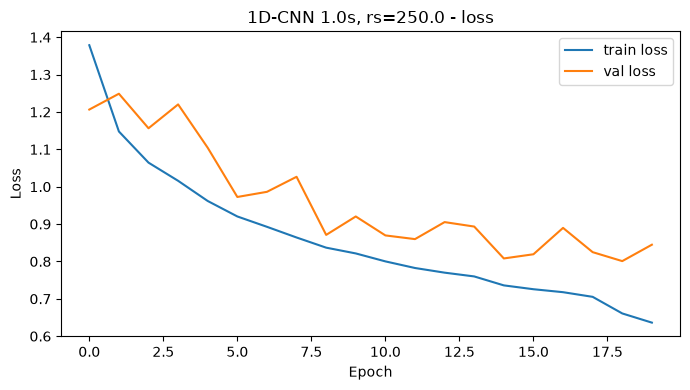

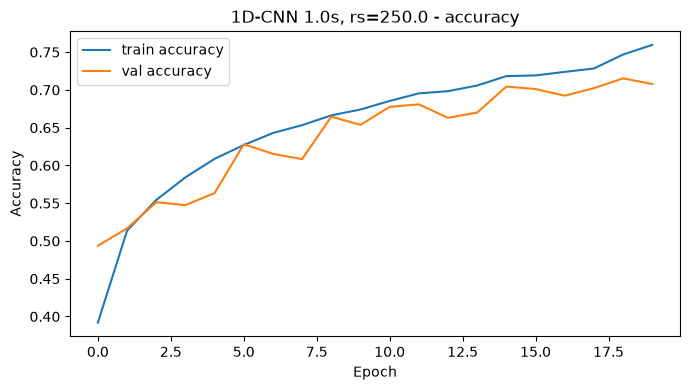

[START] evaluate 1D-CNN 1.0s rs=250.0
[END] evaluate 1D-CNN 1.0s rs=250.0 - elapsed: 1.53s (0.03 min)
1D-CNN 1.0s rs=250.0 test loss: 0.8147
1D-CNN 1.0s rs=250.0 test accuracy: 0.7014

              precision    recall  f1-score   support

     Disgust     0.5674    0.6499    0.6059       557
        Fear     0.7753    0.5752    0.6605       678
         Sad     0.6239    0.7937    0.6986       863
     Neutral     0.7557    0.7432    0.7494       666
       Happy     0.9354    0.7135    0.8095       548

    accuracy                         0.7014      3312
   macro avg     0.7315    0.6951    0.7048      3312
weighted avg     0.7234    0.7014    0.7038      3312



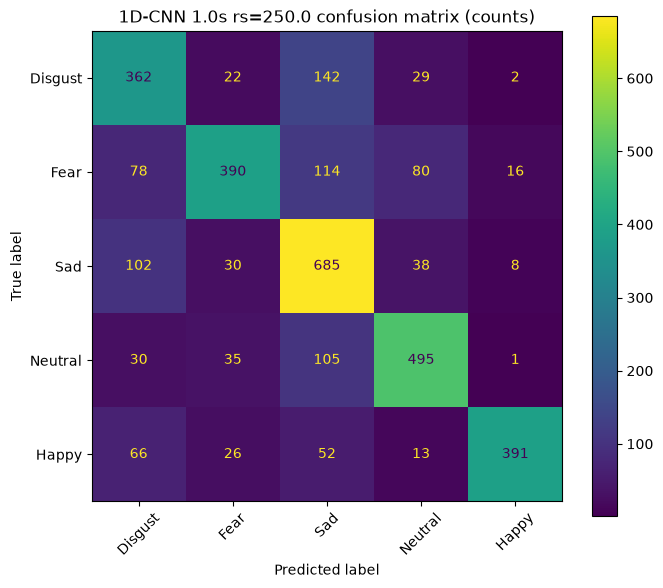

Training 2d_cnn. Target path: outputs\models\win_1p0s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz\model_2d_cnn.keras
[START] train EEG_2D_CNN
Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.2920 - loss: 1.5410 - val_accuracy: 0.2014 - val_loss: 2.4200 - learning_rate: 0.0010
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.3762 - loss: 1.4182 - val_accuracy: 0.3312 - val_loss: 1.8857 - learning_rate: 0.0010
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.4559 - loss: 1.2906 - val_accuracy: 0.4351 - val_loss: 1.4102 - learning_rate: 0.0010
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.5083 - loss: 1.1806 - val_accuracy: 0.5329 - val_loss: 1.1433 - learning_rate: 0.0010
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.5624 - loss: 1.0826 - val_accuracy: 0.5208 - val_loss: 1.2118 - learning_rate: 0.0010
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.5983 - loss: 1.0015 - val_accuracy: 0.57

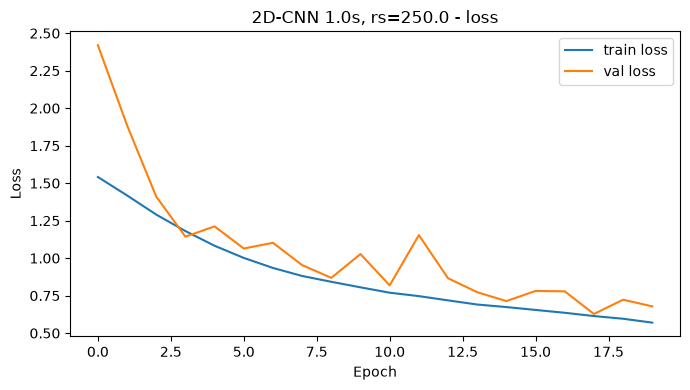

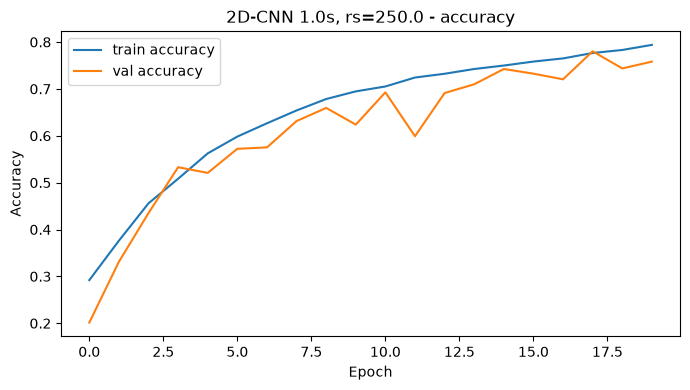

[START] evaluate 2D-CNN 1.0s rs=250.0
[END] evaluate 2D-CNN 1.0s rs=250.0 - elapsed: 17.76s (0.30 min)
2D-CNN 1.0s rs=250.0 test loss: 0.6541
2D-CNN 1.0s rs=250.0 test accuracy: 0.7630

              precision    recall  f1-score   support

     Disgust     0.6632    0.6858    0.6743       557
        Fear     0.7847    0.6667    0.7209       678
         Sad     0.8076    0.7149    0.7585       863
     Neutral     0.7543    0.8529    0.8006       666
       Happy     0.7900    0.9270    0.8531       548

    accuracy                         0.7630      3312
   macro avg     0.7600    0.7695    0.7615      3312
weighted avg     0.7650    0.7630    0.7607      3312



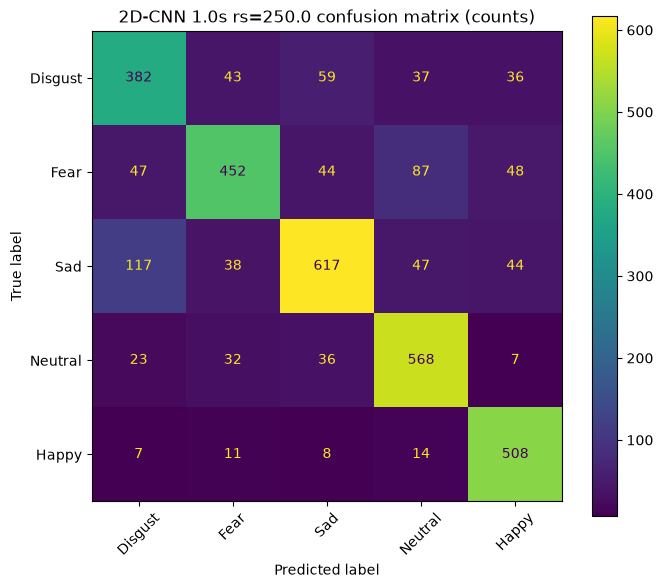

[START] load cached segmented dataset from outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz
[END] load cached segmented dataset from outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz - elapsed: 6.10s (0.10 min)

Configuration: win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz
X: (14691, 62, 375)
y: (14691,)
Dataset cache: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\datasets\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz

TRAIN split (10283 samples)
  Disgust : 1728
  Fear    : 2104
  Sad     : 2682
  Neutral : 2068
  Happy   : 1701

VAL split (2204 samples)
  Disgust : 370
  Fear    : 451
  Sad     : 574
  Neutral : 444
  Happy   : 365

TEST split (2204 samples)
  Disgust : 371
  Fear    : 451
  Sad     : 575
  Neutral : 443
  Happy   : 364
Training 1d_cnn. Target path: outputs\models\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz\model_1d_cnn.keras
[START] train EEG_1D_CNN
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.3664 - loss: 1.3896 - val_accuracy: 0.4569 - val_loss: 1.2643

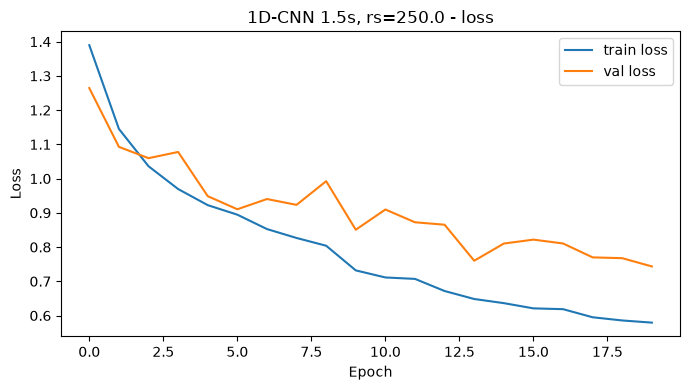

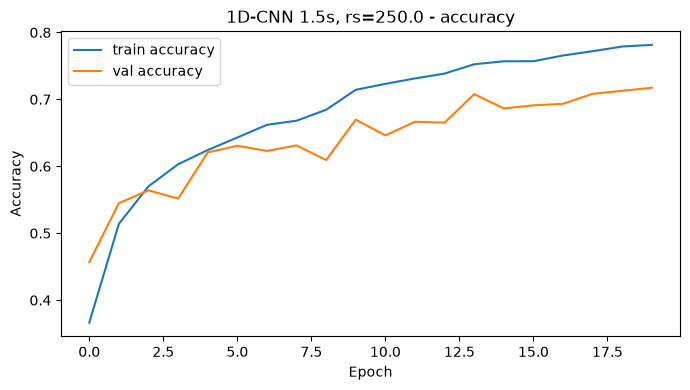

[START] evaluate 1D-CNN 1.5s rs=250.0
[END] evaluate 1D-CNN 1.5s rs=250.0 - elapsed: 1.22s (0.02 min)
1D-CNN 1.5s rs=250.0 test loss: 0.7808
1D-CNN 1.5s rs=250.0 test accuracy: 0.7028

              precision    recall  f1-score   support

     Disgust     0.6793    0.4340    0.5296       371
        Fear     0.5488    0.8226    0.6584       451
         Sad     0.7322    0.6800    0.7051       575
     Neutral     0.7570    0.7946    0.7753       443
       Happy     0.9384    0.7527    0.8354       364

    accuracy                         0.7028      2204
   macro avg     0.7311    0.6968    0.7008      2204
weighted avg     0.7248    0.7028    0.7016      2204



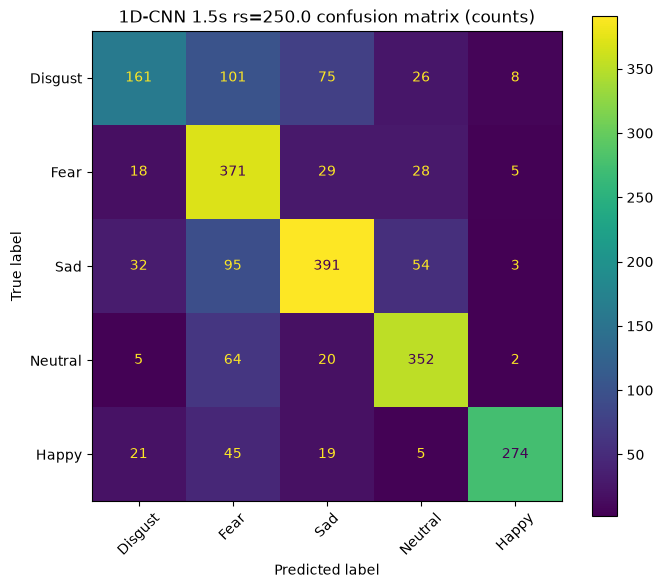

Training 2d_cnn. Target path: outputs\models\win_1p5s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz\model_2d_cnn.keras
[START] train EEG_2D_CNN
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.3046 - loss: 1.5378 - val_accuracy: 0.2015 - val_loss: 3.6396 - learning_rate: 0.0010
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.3790 - loss: 1.4270 - val_accuracy: 0.2786 - val_loss: 3.5484 - learning_rate: 0.0010
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.4331 - loss: 1.3139 - val_accuracy: 0.3162 - val_loss: 2.5809 - learning_rate: 0.0010
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.4848 - loss: 1.2301 - val_accuracy: 0.3358 - val_loss: 1.9846 - learning_rate: 0.0010
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.5254 - loss: 1.1562 - val_accuracy: 0.4093 - val_loss: 1.6213 - learning_rate: 0.0010
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.5604 - loss: 1.0816 - val_accuracy: 0.52

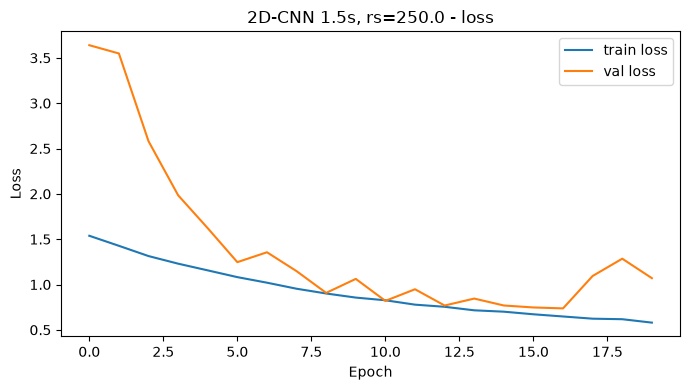

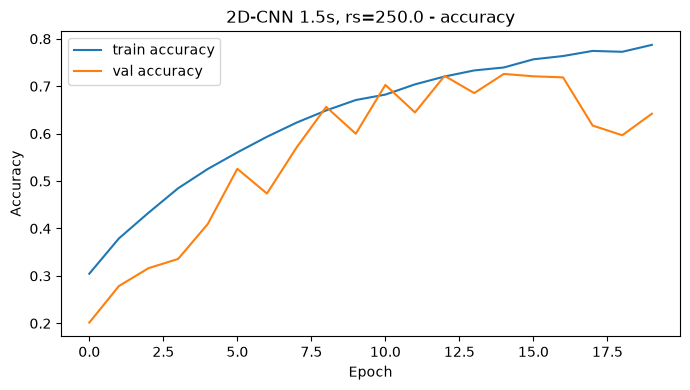

[START] evaluate 2D-CNN 1.5s rs=250.0
[END] evaluate 2D-CNN 1.5s rs=250.0 - elapsed: 18.56s (0.31 min)
2D-CNN 1.5s rs=250.0 test loss: 0.7781
2D-CNN 1.5s rs=250.0 test accuracy: 0.7055

              precision    recall  f1-score   support

     Disgust     0.5122    0.7332    0.6031       371
        Fear     0.6888    0.6430    0.6651       451
         Sad     0.6980    0.7757    0.7348       575
     Neutral     0.8799    0.6117    0.7217       443
       Happy     0.9049    0.7582    0.8251       364

    accuracy                         0.7055      2204
   macro avg     0.7368    0.7044    0.7100      2204
weighted avg     0.7356    0.7055    0.7106      2204



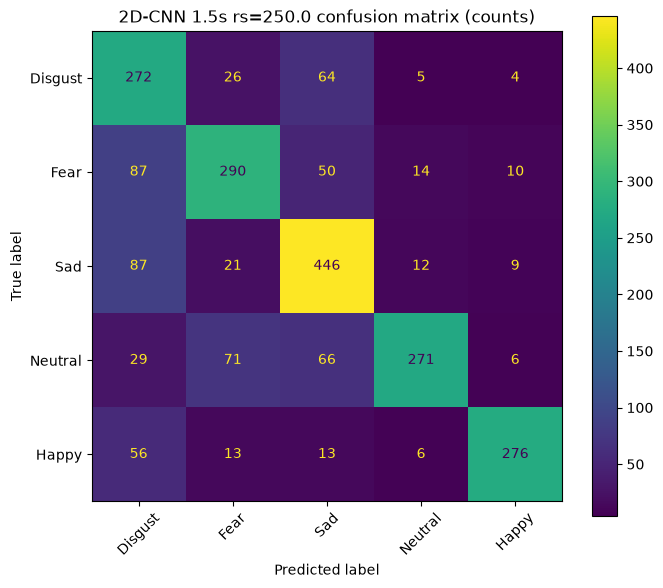

[START] build segmented dataset [win_2p0s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz]
Processing subject=1, session=1, file=1_1_20180804.cnt
[START] load + preprocess 1_1_20180804.cnt
[END] load + preprocess 1_1_20180804.cnt - elapsed: 19.94s (0.33 min)
[START] segment 1_1_20180804.cnt
[END] segment 1_1_20180804.cnt - elapsed: 0.41s (0.01 min)
[START] save cached recording 1_1_20180804_segments.npz
[END] save cached recording 1_1_20180804_segments.npz - elapsed: 7.50s (0.13 min)
Processing subject=1, session=2, file=1_2_20180810.cnt
[START] load + preprocess 1_2_20180810.cnt
[END] load + preprocess 1_2_20180810.cnt - elapsed: 18.38s (0.31 min)
[START] segment 1_2_20180810.cnt
[END] segment 1_2_20180810.cnt - elapsed: 0.36s (0.01 min)
[START] save cached recording 1_2_20180810_segments.npz
[END] save cached recording 1_2_20180810_segments.npz - elapsed: 5.98s (0.10 min)
Processing subject=1, session=3, file=1_3_20180808.cnt
[START] load + preprocess 1_3_20180808.cnt
[END] load + preprocess 1_3_20180

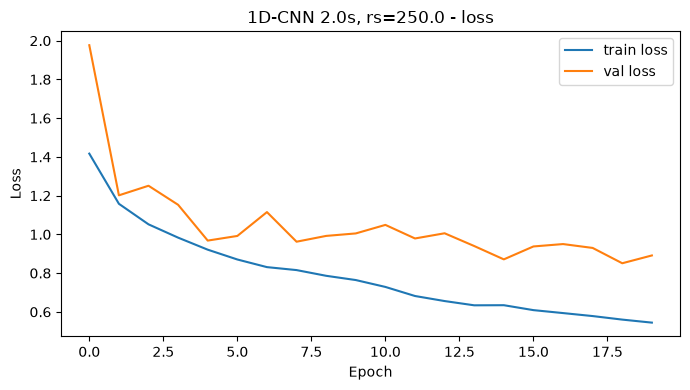

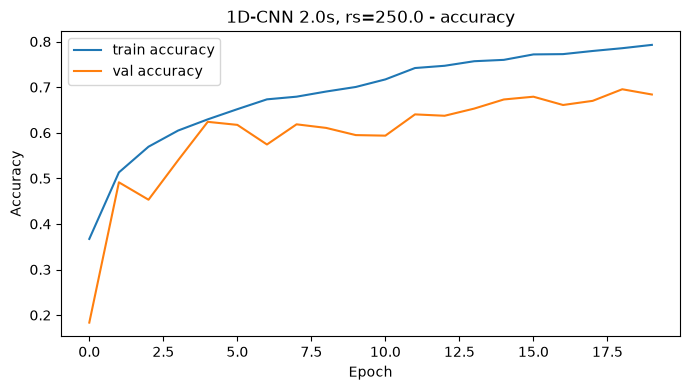

[START] evaluate 1D-CNN 2.0s rs=250.0
[END] evaluate 1D-CNN 2.0s rs=250.0 - elapsed: 1.49s (0.02 min)
1D-CNN 2.0s rs=250.0 test loss: 0.7851
1D-CNN 2.0s rs=250.0 test accuracy: 0.7141

              precision    recall  f1-score   support

     Disgust     0.6250    0.6295    0.6272       278
        Fear     0.5905    0.8131    0.6841       337
         Sad     0.8034    0.5499    0.6529       431
     Neutral     0.7225    0.8705    0.7896       332
       Happy     0.9623    0.7473    0.8412       273

    accuracy                         0.7141      1651
   macro avg     0.7407    0.7220    0.7190      1651
weighted avg     0.7399    0.7141    0.7136      1651



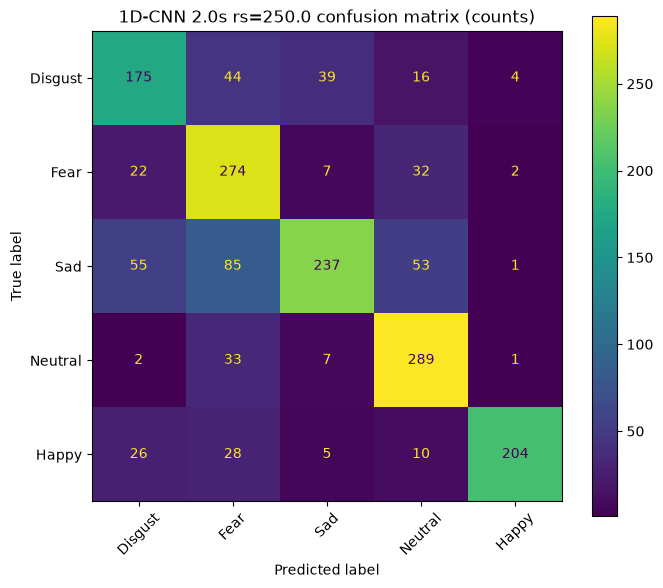

Training 2d_cnn. Target path: outputs\models\win_2p0s_rs_250p0Hz_lf_1p0Hz_hf_50p0Hz\model_2d_cnn.keras
[START] train EEG_2D_CNN
Epoch 1/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 314s 3s/step - accuracy: 0.2980 - loss: 1.5442 - val_accuracy: 0.2029 - val_loss: 2.7883 - learning_rate: 0.0010
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.3770 - loss: 1.4379 - val_accuracy: 0.2653 - val_loss: 3.5514 - learning_rate: 0.0010
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - accuracy: 0.4339 - loss: 1.3287 - val_accuracy: 0.2932 - val_loss: 2.9531 - learning_rate: 0.0010
Epoch 4/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.4727 - loss: 1.2407 - val_accuracy: 0.2744 - val_loss: 1.9384 - learning_rate: 0.0010
Epoch 5/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.5178 - loss: 1.1584 - val_accuracy: 0.3283 - val_loss: 1.7352 - learning_rate: 0.0010
Epoch 6/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.5499 - loss: 1.0948 - val_accuracy: 0.44

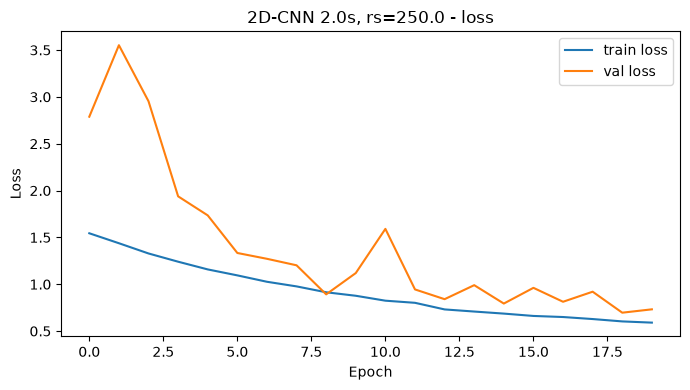

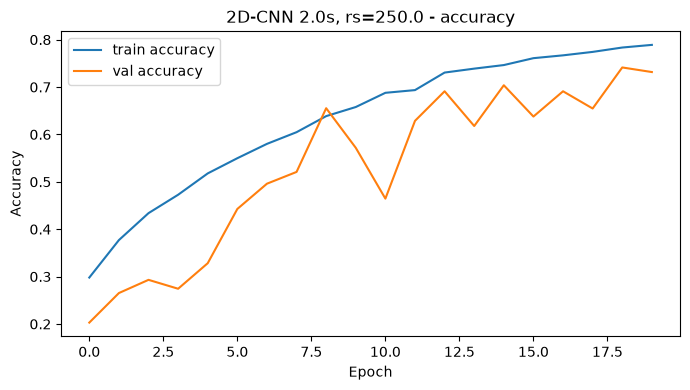

[START] evaluate 2D-CNN 2.0s rs=250.0
[END] evaluate 2D-CNN 2.0s rs=250.0 - elapsed: 17.99s (0.30 min)
2D-CNN 2.0s rs=250.0 test loss: 0.6402
2D-CNN 2.0s rs=250.0 test accuracy: 0.7729

              precision    recall  f1-score   support

     Disgust     0.6879    0.6978    0.6929       278
        Fear     0.7621    0.6083    0.6766       337
         Sad     0.8377    0.7425    0.7872       431
     Neutral     0.6987    0.9428    0.8026       332
       Happy     0.9037    0.8938    0.8987       273

    accuracy                         0.7729      1651
   macro avg     0.7780    0.7770    0.7716      1651
weighted avg     0.7800    0.7729    0.7703      1651



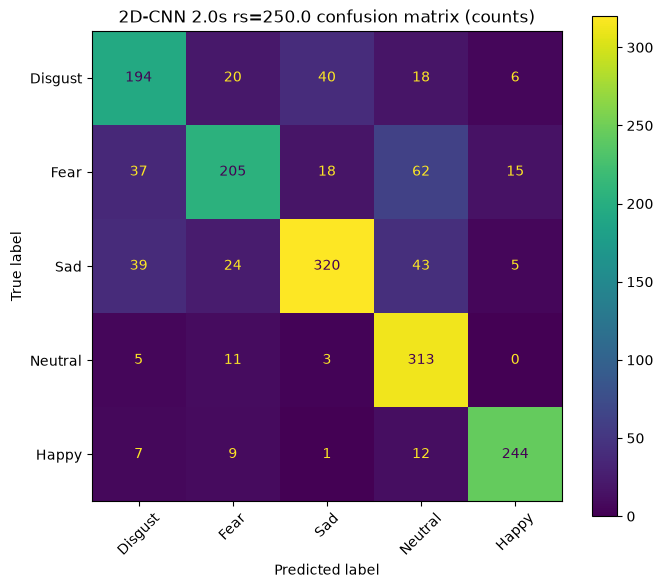

,window_seconds,resample_freq,model,test_loss,test_accuracy,n_samples,trained_in_this_run
0,1.0,250.0,1D-CNN,0.814680,0.701389,22077,True
1,1.0,250.0,2D-CNN,0.654138,0.762983,22077,True
2,1.5,250.0,1D-CNN,0.780757,0.702813,14691,True
3,1.5,250.0,2D-CNN,0.778086,0.705535,14691,True
4,2.0,250.0,1D-CNN,0.785057,0.714113,11004,True
5,2.0,250.0,2D-CNN,0.640175,0.772865,11004,True


Saved window results: C:\Users\Ricc\Desktop\Progetto_CVT\outputs\results\window_duration_results_rs_250p0Hz.csv


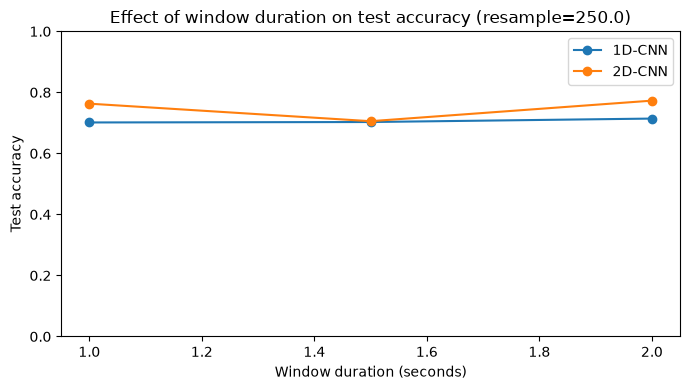

Resampling experiments are disabled. Set RUN_RESAMPLE_EXPERIMENTS = True to run them.


In [26]:
all_experiment_results = []

if RUN_WINDOW_EXPERIMENTS:
    window_results = []

    for ws in WINDOW_SECONDS_LIST:
        results_ws, models_ws = run_config_experiment(
            window_seconds=ws,
            resample_freq=RESAMPLE_FREQ,
            epochs=EXPERIMENT_EPOCHS,
            batch_size=BATCH_SIZE,
            patience=EXPERIMENT_PATIENCE,
            train_1d=TRAIN_WINDOW_1D,
            train_2d=TRAIN_WINDOW_2D,
            force_retrain=FORCE_RETRAIN_WINDOW_MODELS,
        )
        window_results.append(results_ws)

    window_results_table = pd.concat(window_results, ignore_index=True)
    display(window_results_table)

    window_results_path = RESULTS_SEED_DIR / f"window_duration_results_rs_{_safe_float_token(RESAMPLE_FREQ, 'Hz')}_{seed_tag()}.csv"
    window_results_table.to_csv(window_results_path, index=False)
    print("Saved window results:", window_results_path.resolve())

    window_plot_tag = run_output_tag("window_duration_accuracy_comparison", DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ)
    fig, ax = plt.subplots(figsize=(7, 4))
    for model_name, model_df in window_results_table.groupby("model"):
        model_df = model_df.sort_values("window_seconds")
        ax.plot(model_df["window_seconds"], model_df["test_accuracy"], marker="o", label=model_name)

    ax.set_ylim(0, 1)
    ax.set_title(f"Effect of window duration on test accuracy (resample={RESAMPLE_FREQ}, {seed_tag()})")
    ax.set_xlabel("Window duration (seconds)")
    ax.set_ylabel("Test accuracy")
    ax.legend()
    fig.tight_layout()
    save_figure(fig, PLOTS_SEED_DIR / f"{window_plot_tag}.png")
    plt.show()

    all_experiment_results.append(window_results_table)
else:
    print("Window experiments are disabled. Set RUN_WINDOW_EXPERIMENTS = True to run them.")


if RUN_RESAMPLE_EXPERIMENTS:
    resample_results = []

    for rs in RESAMPLE_FREQ_LIST:
        results_rs, models_rs = run_config_experiment(
            window_seconds=DEFAULT_WINDOW_SECONDS,
            resample_freq=rs,
            epochs=EXPERIMENT_EPOCHS,
            batch_size=BATCH_SIZE,
            patience=EXPERIMENT_PATIENCE,
            train_1d=TRAIN_RESAMPLE_1D,
            train_2d=TRAIN_RESAMPLE_2D,
            force_retrain=FORCE_RETRAIN_RESAMPLE_MODELS,
        )
        resample_results.append(results_rs)

    resample_results_table = pd.concat(resample_results, ignore_index=True)
    display(resample_results_table)

    resample_results_path = RESULTS_SEED_DIR / f"resample_results_win_{_safe_float_token(DEFAULT_WINDOW_SECONDS, 's')}_{seed_tag()}.csv"
    resample_results_table.to_csv(resample_results_path, index=False)
    print("Saved resample results:", resample_results_path.resolve())

    resample_plot_tag = run_output_tag("resampling_accuracy_comparison", DEFAULT_WINDOW_SECONDS, RESAMPLE_FREQ, LOW_FREQ, HIGH_FREQ)
    fig, ax = plt.subplots(figsize=(7, 4))
    for model_name, model_df in resample_results_table.groupby("model"):
        model_df = model_df.sort_values("resample_freq")
        ax.plot(model_df["resample_freq"], model_df["test_accuracy"], marker="o", label=model_name)

    ax.set_ylim(0, 1)
    ax.set_title(f"Effect of resampling frequency on test accuracy ({DEFAULT_WINDOW_SECONDS}s windows, {seed_tag()})")
    ax.set_xlabel("Resampling frequency (Hz)")
    ax.set_ylabel("Test accuracy")
    ax.legend()
    fig.tight_layout()
    save_figure(fig, PLOTS_SEED_DIR / f"{resample_plot_tag}.png")
    plt.show()

    all_experiment_results.append(resample_results_table)
else:
    print("Resampling experiments are disabled. Set RUN_RESAMPLE_EXPERIMENTS = True to run them.")


## 20. Notes for the presentation

When reporting results, include:

1. number of segments per class;
2. final train/validation/test distribution;
3. 1D-CNN architecture and input shape;
4. 2D-CNN architecture and input shape;
5. baseline test accuracy and confusion matrices;
6. comparison between 1D and 2D models;
7. effect of window duration;
8. optional effect of resampling frequency/computational cost;
9. discussion of class imbalance and inter-subject variability.

Important caveat: random segment-level splitting may overestimate generalization because nearby EEG windows can be correlated. Subject-wise or session-wise evaluation is stricter and should be discussed as a limitation or additional experiment.